In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

print(train_images.shape)
print(test_images.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(10000, 28, 28)


In [ ]:
train_images = train_images.reshape(-1, 28, 28, 1)
test_images = test_images.reshape(-1, 28, 28, 1)

In [ ]:
train_images, test_images = train_images / 255.0, test_images / 255.0

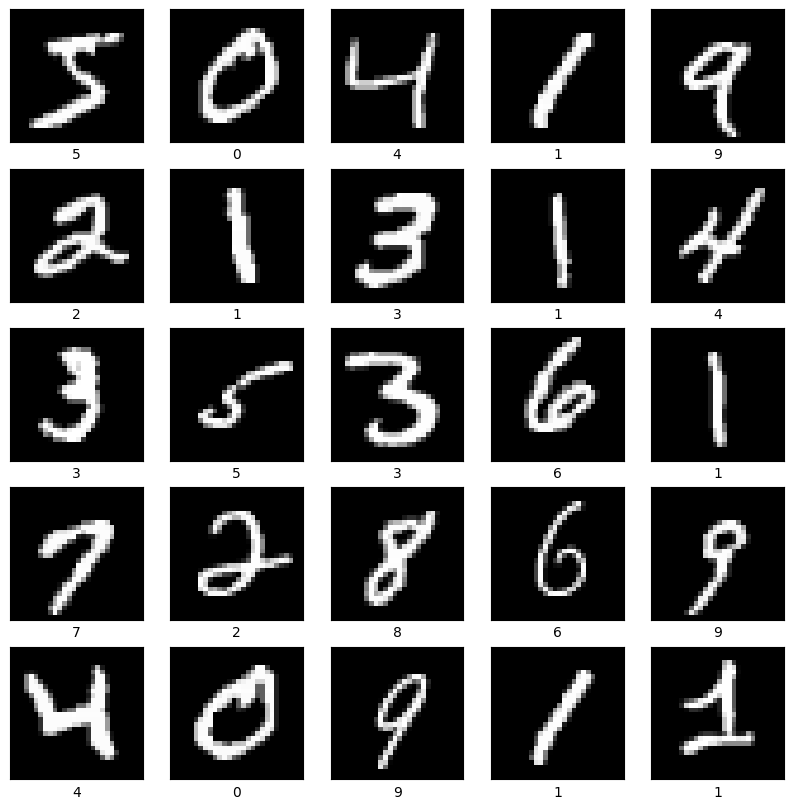

In [ ]:
class_names = [
    '0', '1', '2', '3', '4',
    '5', '6', '7', '8', '9'
]

plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.imshow(train_images[i].reshape(28, 28), cmap='gray')

    plt.xlabel(class_names[train_labels[i]])

plt.show()

In [ ]:
model = models.Sequential()

model.add(
    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    )
)

model.add(layers.MaxPooling2D((2, 2)))

model.add(
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    )
)

model.add(layers.MaxPooling2D((2, 2)))

model.add(
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    )
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,744 (217.75 KB)

 Trainable params: 55,744 (217.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.add(layers.Flatten())

model.add(
    layers.Dense(
        64,
        activation='relu'
    )
)

model.add(
    layers.Dense(
        10
    )
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [ ]:
train_labels_categorical = to_categorical(train_labels)

test_labels_categorical = to_categorical(test_labels)

In [ ]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(
        from_logits=True
    ),
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_images,
    train_labels_categorical,
    epochs=10,
    validation_split=0.1,
    batch_size=128
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 46s 104ms/step - accuracy: 0.9194 - loss: 0.2621 - val_accuracy: 0.9780 - val_loss: 0.0773
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 100ms/step - accuracy: 0.9802 - loss: 0.0639 - val_accuracy: 0.9858 - val_loss: 0.0515
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 99ms/step - accuracy: 0.9857 - loss: 0.0445 - val_accuracy: 0.9873 - val_loss: 0.0483
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 101ms/step - accuracy: 0.9893 - loss: 0.0346 - val_accuracy: 0.9872 - val_loss: 0.0462
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 97ms/step - accuracy: 0.9908 - loss: 0.0287 - val_accuracy: 0.9890 - val_loss: 0.0406
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 96ms/step - accuracy: 0.9926 - loss: 0.0233 - val_accuracy: 0.9903 - val_loss: 0.0366
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9929 - loss: 0.0215 - val_accuracy: 0.9890 - val_loss: 0.0374
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 98ms/step - accuracy: 0.9947 - loss: 0.0165

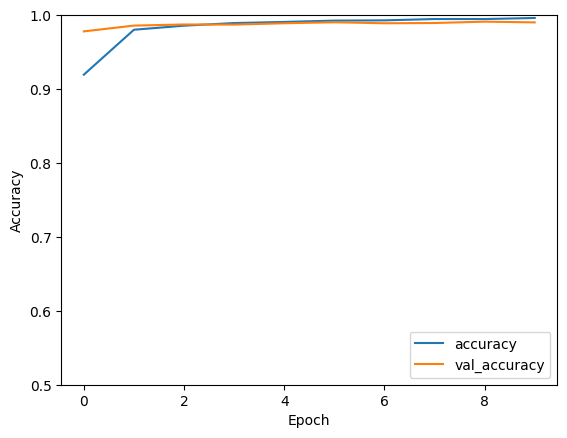

In [ ]:
plt.plot(
    history.history['accuracy'],
    label='accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='val_accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.ylim([0.5, 1])

plt.legend(loc='lower right')

plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(
    test_images,
    test_labels_categorical,
    verbose=2
)

print("Test Accuracy:", test_acc)
print("Test Accuracy %:", test_acc * 100)

313/313 - 3s - 9ms/step - accuracy: 0.9928 - loss: 0.0266
Test Accuracy: 0.9927999973297119
Test Accuracy %: 99.27999973297119
